<a href="https://colab.research.google.com/github/Malicef/Sistemas-Inteligentes/blob/main/projeto3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Disciplina: PAM0466– SISTEMAS INTELIGENTES

Docente: Pedro Thiago Valerio de Souza

Discentes: Maria Alice Ferreira Teixeira e Thiago Luan Moreira Sousa

3ª PROJETO

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

#Muda a fonte dos Plots para Arial
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams['mathtext.rm'] = "Arial"
plt.rcParams['mathtext.it'] = "Arial:italic"
plt.rcParams['mathtext.bf'] = "Arial:bold"
plt.rcParams['figure.figsize'] = (8, 4)

In [2]:
#Carregar o dataset
df = pd.read_csv('winequality-red.csv', sep=';')
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [3]:
# Recondificando as classes

def categorizar(qualidade):
    if qualidade <= 5:
        return 'ruim'
    elif qualidade <= 7:
        return 'medio'
    else:
        return 'bom'

df['qualidade_cat'] = df['quality'].apply(categorizar)

In [4]:
# Separando features e target

X = df.drop(['quality', 'qualidade_cat'], axis=1)
y = df['qualidade_cat']

In [6]:

# Normalizando

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


**1. Porque a normalização é uma etapa obrigatória para o k-NN?**

O k-NN utiliza medidas de distância (geralmente euclidiana) para classificar os dados. Como os atributos do dataset possuem escalas muito diferentes, aqueles com valores maiores dominariam o cálculo da distância. Isso faria com que variáveis menores fossem praticamente ignoradas.
A normalização coloca todos os atributos na mesma escala, garantindo que cada um contribua de forma equilibrada para a decisão do modelo.


In [7]:
# Dividindo sets de treino e de teste

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 1279 amostras
Teste:  320 amostras


In [8]:

# Testando valores diferentes de K

k_values = [1, 3, 5, 7, 11]
scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(model, X_train, y_train, cv=5)
    scores.append(cv_score.mean())

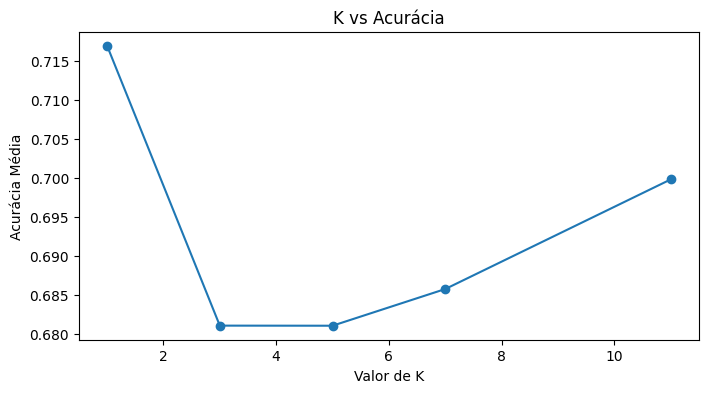

In [15]:

# Plotando o gráfico

plt.plot(k_values, scores, marker='o')
plt.xlabel('Valor de K')
plt.ylabel('Acurácia Média')
plt.title('K vs Acurácia')
plt.show()

**3. O que acontece com o modelo para valores muito baixos e muito altos de k?**

**k muito baixo (ex: 1):**
O modelo sofre de overfitting, pois considera apenas um vizinho e se torna muito sensível a ruídos e outliers. Ele memoriza os dados de treino, mas generaliza mal.

**k muito alto:**
O modelo sofre de underfitting, pois considera muitos vizinhos e perde a capacidade de capturar padrões locais, tendendo a prever a classe majoritária.

In [10]:

# Escolhendo melhor K

best_k = k_values[np.argmax(scores)]
print("Melhor K:", best_k)

Melhor K: 1


In [11]:

# Treinando o modelo

model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [12]:

# Avaliando

y_pred = model.predict(X_test)

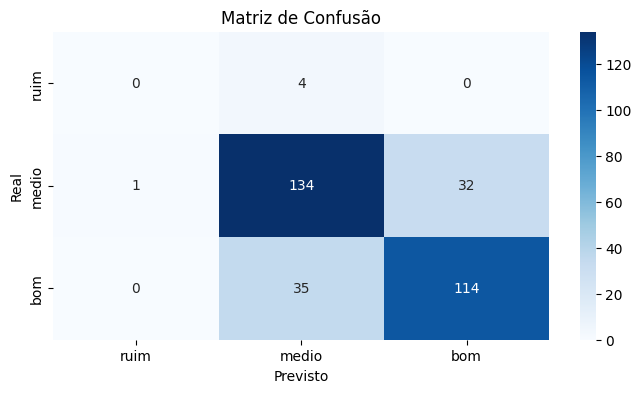

In [13]:

# Gerar a matriz de confusão

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ruim','medio','bom'],
            yticklabels=['ruim','medio','bom'])

plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

In [14]:
# Printando as Métricas

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         bom       0.00      0.00      0.00         4
       medio       0.77      0.80      0.79       167
        ruim       0.78      0.77      0.77       149

    accuracy                           0.78       320
   macro avg       0.52      0.52      0.52       320
weighted avg       0.77      0.78      0.77       320



**4. Entre quais classes o modelo erra com mais frequência?**

O relatório de classificação mostra que o modelo apresenta maior dificuldade na classe “bom” (notas ≥ 8), que obteve valores de precision, recall e F1-score iguais a 0.00, indicando que nenhuma amostra dessa classe foi corretamente prevista. Esse resultado ocorre principalmente devido ao forte desbalanceamento do conjunto de dados, já que a classe “bom” representa cerca de 1% das amostras, o que dificulta o aprendizado de seus padrões. Além disso, observa-se que a principal confusão acontece entre as classes “ruim” e “médio”, pois são mais numerosas e possuem características semelhantes, tornando a separação entre elas mais difícil. Outro fator que contribui para esse comportamento é o uso de k = 1, que favorece o overfitting, fazendo com que o modelo memorize os dados de treino e tenha baixa capacidade de generalização. Assim, apesar da acurácia geral ser de aproximadamente 78%, o desempenho é desequilibrado, sendo mais adequado utilizar valores de k como 3 ou 5 para obter uma classificação mais robusta.